In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
BATCH_SIZE = 256
NUM_EPOCHS = 10
LR = 0.01

In [3]:
tfs = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST('.', train=True, transform=tfs, download=True)
test_dataset = datasets.MNIST('.', train=False, transform=tfs, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

len(train_dataset), len(test_dataset)

Failed to download (trying next):
<urlopen error [Errno 60] Operation timed out>



100%|██████████| 9912422/9912422 [00:02<00:00, 4926372.43it/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 60] Operation timed out>



100%|██████████| 28881/28881 [00:00<00:00, 212745.32it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 60] Operation timed out>



100%|██████████| 1648877/1648877 [01:29<00:00, 18462.86it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 60] Operation timed out>



100%|██████████| 4542/4542 [00:00<00:00, 8141251.61it/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



(60000, 10000)

In [4]:
def show_img(img, label):
    print('Label: ', label)
    plt.imshow(img.permute(1,2,0), cmap = 'gray')

show_img(*train_dataset[0])

Label:  5


In [5]:
class LeNet(torch.nn.Module):
    def __init__(self, num_classes):
        super(LeNet, self).__init__()
        self.num_classes = num_classes

        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(1, 6, kernel_size=5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Conv2d(6, 16, kernel_size = 5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2))

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(16*5*5, 120),
            torch.nn.ReLU(),
            torch.nn.Linear(120, 84),
            torch.nn.ReLU(),
            torch.nn.Linear(84, self.num_classes))

    def forward(self, x):
        x = self.features(x)
        y = self.classifier(x)
        return y

In [6]:
def train(model, loss, trainer, train, test, num_epochs):
    print_train_acc, print_test_acc = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_acc, train_n = 0.0, 0.0, 0
        test_acc, test_n = torch.Tensor([0]), 0

        for X, y in train:
            trainer.zero_grad()
            y_pred = model(X)

            l = loss(y_pred, y)
            l.backward()
            trainer.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(axis=1) == y).sum().item()
            train_n += y.shape[0]

        for X, y in test:
            model.eval()
            test_acc += (model(X).argmax(axis=1) == y).sum()
            test_n += y.shape[0]

        train_acc = train_acc / train_n
        test_acc = test_acc.item() / test_n

        print_train_acc.append(train_acc)
        print_test_acc.append(test_acc)

        print(f'epoch: {epoch}, train_loss: {train_loss}, train_acc: {train_acc}, test_acc: {test_acc}')

    return print_train_acc, print_test_acc

In [7]:
model = LeNet(len(train_dataset.classes))
loss = torch.nn.CrossEntropyLoss()
trainer = torch.optim.SGD(model.parameters(), lr=LR)

train_acc, test_acc = train(model, loss, trainer, train_loader, test_loader, NUM_EPOCHS)

[W NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


epoch: 0, train_loss: 540.7024042606354, train_acc: 0.10301666666666667, test_acc: 0.1046
epoch: 1, train_loss: 539.7747182846069, train_acc: 0.11703333333333334, test_acc: 0.1135
epoch: 2, train_loss: 537.9284205436707, train_acc: 0.11796666666666666, test_acc: 0.1749
epoch: 3, train_loss: 530.9786906242371, train_acc: 0.23925, test_acc: 0.3172
epoch: 4, train_loss: 433.7251179218292, train_acc: 0.4366333333333333, test_acc: 0.6868
epoch: 5, train_loss: 177.9178108870983, train_acc: 0.7682666666666667, test_acc: 0.8383
epoch: 6, train_loss: 113.344522356987, train_acc: 0.8490166666666666, test_acc: 0.8811
epoch: 7, train_loss: 90.93880978226662, train_acc: 0.8812, test_acc: 0.8882
epoch: 8, train_loss: 78.38646434247494, train_acc: 0.8963166666666667, test_acc: 0.9146
epoch: 9, train_loss: 68.4256649017334, train_acc: 0.9102, test_acc: 0.923


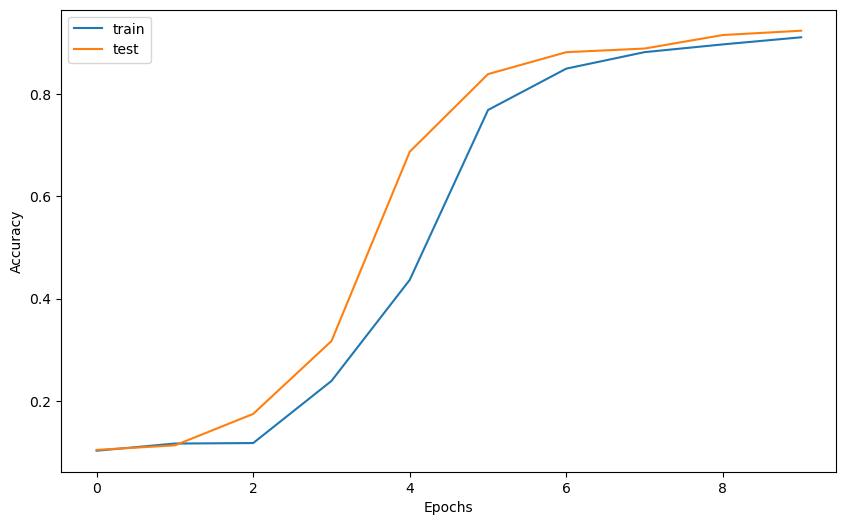

In [104]:
plt.figure(figsize = (10,6))
plt.plot(train_acc, label = 'train')
plt.plot(test_acc, label = 'test')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [17]:
def predict(img, model):
    pred = model(img.unsqueeze(0))
    _, preds  = torch.max(pred, dim=1)
    return preds[0].item()

Предсказания модели:

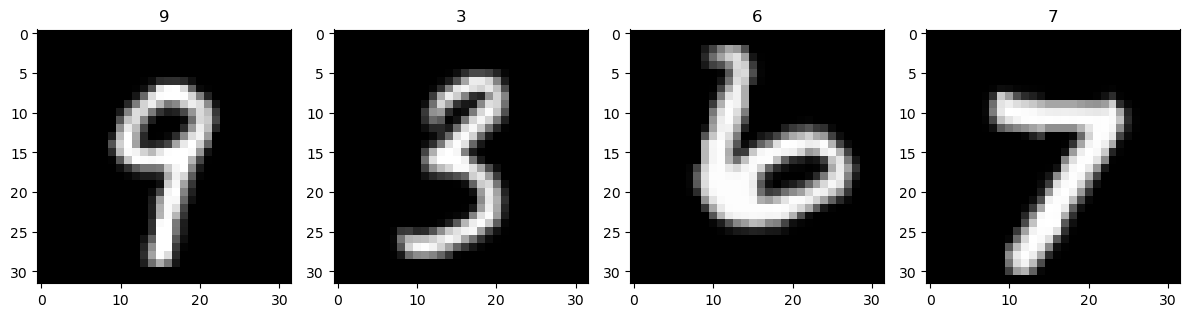

In [108]:
fig_print = plt.figure(figsize=(12, 4))
rows, cols = 1, 4

for i in range(rows * cols):
    idx = torch.randint(0, len(test_dataset), size=[1]).item()
    img, label = test_dataset[idx]

    pred = torch.max(model(img.unsqueeze(0)), dim=1)[0].item()
    pred = predict(img, model)

    fig_print.add_subplot(rows, cols, i+1)
    plt.imshow(img[0], cmap='gray')
    plt.title(pred)
    plt.tight_layout()

plt.show()

# Добавление шума

In [31]:
def add_noise(image, epsilon, data_grad):
    image = image + epsilon * data_grad.sign()
    image = torch.clamp(image, 0, 1)
    
    return image

step = 17, epsilon = 0.17


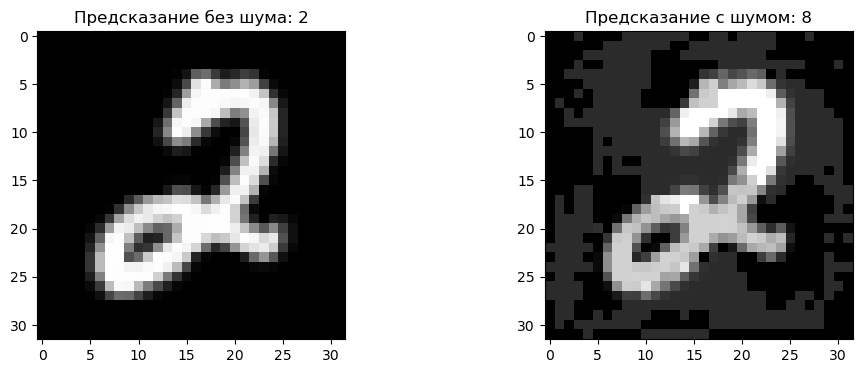

In [122]:
num_epochs = 50
epsilon = 0
idx = torch.randint(0, len(test_dataset), size=[1]).item()

for epoch in range(num_epochs):
    model.eval()

    img, label = test_dataset[idx]
    clear_img = img
    img = img.unsqueeze(0)
    img.requires_grad = True
    pred = model(img)

    l = loss(pred[0], torch.tensor(label))
    model.zero_grad()
    l.backward()
    data_grad = img.grad.data

    img_with_noise = add_noise(img, epsilon, data_grad)
    pred_with_noise = model(img_with_noise)

    if torch.argmax(pred, 1).item() == torch.argmax(pred_with_noise, 1).item():
        epsilon += LR
    else:
        print(f'step = {epoch}, epsilon = {epsilon}')
        fig = plt.figure(figsize=(12, 4))

        fig.add_subplot(1, 2, 1)
        plt.imshow(clear_img[0], cmap='gray')
        plt.title(f'Предсказание без шума: {str(torch.argmax(pred, 1).item())}')

        fig.add_subplot(1, 2, 2)
        plt.imshow(np.squeeze(img_with_noise.detach()), cmap='gray')
        plt.title(f'Предсказание с шумом: {str(torch.argmax(pred_with_noise, 1).item())}')
        plt.show()

        break